# Aim 1, step 2b — Simulations with known ground truth

**Goal:** show, with data where the right answer is known, how each technical source creates spurious donor differences, and which analysis choices remove it.

**Simulated at pseudobulk level:** 24 donors, 20 responsive + 6 inert cytokines, 500 genes. Each donor's response to cytokine $c$ is split into two random halves of cells (A, B). Knobs:
- **truth**: `null` (donors identical), `size` (donors differ only in response size), `shape_ifn` (high-IFN donors change response shape)
- **cell counts**: random, or fewer cells in high-IFN donors
- **well noise**: shared by both halves of a well
- **reference offset**: control (PBS) wells carry a donor-specific offset, as in an edge row
- **processing date**: a minority date raises the baseline-IFN score and shifts all responses

**Estimators of donor deviation (size / shape):**
- `asym`: half A vs the mean of other donors (the flawed version)
- `sym`: half A of one donor vs half B of another, minus within-donor terms
- `cross`: cross-half inner products ($|z_d|^2 \approx A_d\cdot B_d$, $z_d\cdot z_e \approx (A_d\cdot B_e + B_d\cdot A_e)/2$), which remove independent sampling noise in expectation
- options: compare only within date; subtract well noise estimated from control wells; equalize cell counts across donors (downsampling)

**Readouts (40 replicate simulations each):** `rho` = Spearman(baseline IFN score, shape deviation); `pos_rate` = share of replicates with a significant positive correlation (false-positive rate under `null`, power under `shape_ifn`); `ifn_contrast` = shape deviation of high-IFN minus other donors; `shape_typical` = shape deviation among non-high donors; `share_size` = size share of the deviation among non-high donors (should be about 1 when truth = `size`).

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import spearmanr
RESULTS_DIR = "results/aim1_simulation"
os.makedirs(RESULTS_DIR, exist_ok=True)
REPS = 40

In [2]:
# ---------------------------------------------------------------- simulation
def simulate(rng, truth="null", n_donors=24, n_cyt=20, n_inert=6, G=500,
             resp_norm=5.0, spec_frac=0.5, size_sd=0.4, shape_frac=0.8,
             cells=(100, 400), cells_low_for_high=False, sigma_cell=1.0,
             well_sd=0.0, n_ctrl_wells=6, ref_offset=0.0,
             date_effect=0.0, date_score_shift=1.5, date_frac=0.25):
    """Pseudobulk-level simulation. Returns per-donor half-responses under two references."""
    u = rng.normal(size=G); u /= np.linalg.norm(u)
    beta = rng.gamma(2, 1, n_cyt); beta /= beta.mean()
    spec = rng.normal(size=(n_cyt, G)); spec /= np.linalg.norm(spec, axis=1, keepdims=True)
    Z = beta[:, None] * resp_norm * (np.sqrt(1 - spec_frac ** 2) * u + spec_frac * spec)   # true responses

    latent = rng.normal(size=n_donors)                      # latent baseline-interferon state
    n1 = int(round(date_frac * n_donors))
    date = np.array([0] * (n_donors - n1) + [1] * n1); rng.shuffle(date)
    score = latent + date_score_shift * date * (date_effect > 0) + rng.normal(0, 0.3, n_donors)
    high = latent >= np.quantile(latent, 0.75)
    batch_vec = rng.normal(size=G); batch_vec /= np.linalg.norm(batch_vec)
    ref_dir = rng.normal(size=G); ref_dir /= np.linalg.norm(ref_dir)

    donors = {}
    for d in range(n_donors):
        Zd = Z.copy()
        if truth == "size":                                  # donors differ only in response size
            Zd = Zd * np.exp(rng.normal(0, size_sd, (n_cyt, 1)))
        if truth == "shape_ifn" and high[d]:                 # high-IFN donors change response shape
            eta = rng.normal(size=(n_cyt, G)); eta /= np.linalg.norm(eta, axis=1, keepdims=True)
            Zd = Zd + shape_frac * np.linalg.norm(Zd, axis=1, keepdims=True) * eta
        if date_effect > 0 and date[d] == 1:                 # processing date alters all responses
            Zd = Zd + date_effect * resp_norm * batch_vec
        n = int(rng.integers(*cells)) if not (cells_low_for_high and high[d]) else int(cells[0] * 0.4)
        noise = lambda k: rng.normal(0, sigma_cell / np.sqrt(k), G)

        # control: several wells; each half pools cells from all control wells; edge-row offset on controls
        cw = rng.normal(0, well_sd, (n_ctrl_wells, G))
        offset = ref_offset * resp_norm * abs(rng.normal(1, 0.5)) * ref_dir
        per_well = max(n // n_ctrl_wells, 2)
        ctrl_halves = [cw.mean(0) + offset + noise(n / 2) for _ in range(2)]
        ctrl_wells = [(cw[w] + offset + noise(per_well / 2), cw[w] + offset + noise(per_well / 2))
                      for w in range(n_ctrl_wells)]

        # stimulated wells (one per cytokine) and inert wells (true response 0), no edge offset
        def wells(true):
            w = rng.normal(0, well_sd, (len(true), G))
            return [true + w + np.array([noise(n / 2) for _ in true]) for _ in range(2)]
        SA, SB = wells(Zd)
        IA, IB = wells(np.zeros((n_inert, G)))
        A_pbs, B_pbs = SA - ctrl_halves[0], SB - ctrl_halves[1]
        IA_pbs, IB_pbs = IA - ctrl_halves[0], IB - ctrl_halves[1]
        donors[d] = dict(A_pbs=A_pbs, B_pbs=B_pbs,
                         A_inert=A_pbs - IA_pbs.mean(0), B_inert=B_pbs - IB_pbs.mean(0),
                         ctrl_wells=ctrl_wells, n=n, score=score[d], high=bool(high[d]), date=int(date[d]),
                         sigma=sigma_cell)
    return donors

# ---------------------------------------------------------------- estimators
def mag_shape(a, b):
    na, nb = np.linalg.norm(a, axis=-1), np.linalg.norm(b, axis=-1)
    cos = (a * b).sum(-1) / (na * nb + 1e-12)
    return (na - nb) ** 2, 2 * na * nb * (1 - cos)

def well_term(don):
    # 2 x well-noise energy, estimated from control wells: different wells minus same well
    t = []
    for d in don.values():
        cw = d["ctrl_wells"]
        within = np.mean([np.sum((a - b) ** 2) for a, b in cw])
        between = np.mean([np.sum((cw[i][0] - cw[j][1]) ** 2) for i in range(len(cw)) for j in range(len(cw)) if i != j])
        t.append(max(between - within, 0))
    return np.mean(t)

def cross_parts(Ad, Bd, Ae, Be, wt_half):
    # Unbiased-in-expectation inner products from independent halves:
    #   |z_d|^2 ~ A_d.B_d  (noise of the two halves is independent)
    #   z_d.z_e ~ (A_d.B_e + B_d.A_e) / 2
    # Well noise is shared by the two halves of a well, so its energy is subtracted from the norms.
    nd2 = np.maximum((Ad * Bd).sum(-1) - wt_half, 1e-12)
    ne2 = np.maximum((Ae * Be).sum(-1) - wt_half, 1e-12)
    de = ((Ad * Be).sum(-1) + (Bd * Ae).sum(-1)) / 2
    nd, ne = np.sqrt(nd2), np.sqrt(ne2)
    cos = np.clip(de / (nd * ne), -1, 1)
    return (nd - ne) ** 2, 2 * nd * ne * (1 - cos)

def deviations(don, ref="inert", estimator="sym", same_date=False, well_correct=False, equalize=False, seed=0):
    keys = list(don)
    A = {d: don[d][f"A_{ref}"] for d in keys}; B = {d: don[d][f"B_{ref}"] for d in keys}
    if equalize:
        # match noise across donors, as if every donor were downsampled to the smallest cell count
        rng = np.random.default_rng(seed)
        n_min = min(don[d]["n"] for d in keys)
        for d in keys:
            extra = don[d]["sigma"] ** 2 * (2 / n_min - 2 / don[d]["n"])
            if extra > 0:
                A[d] = A[d] + rng.normal(0, np.sqrt(extra), A[d].shape)
                B[d] = B[d] + rng.normal(0, np.sqrt(extra), B[d].shape)
    energy = np.mean([((A[d] ** 2).sum(1) + (B[d] ** 2).sum(1)).mean() / 2 for d in keys])
    W = {d: mag_shape(A[d], B[d]) for d in keys}
    wt = well_term(don) if well_correct else 0.0
    out = []
    for d in keys:
        others = [e for e in keys if e != d and (not same_date or don[e]["date"] == don[d]["date"])]
        if not others: continue
        if estimator == "cross":
            parts = [cross_parts(A[d], B[d], A[e], B[e], wt / 2) for e in others]
            size = np.mean([p[0] for p in parts], 0); shape = np.mean([p[1] for p in parts], 0)
        elif estimator == "asym":
            m = np.mean([(A[e] + B[e]) / 2 for e in others], 0)
            M, S = mag_shape(A[d], m)
            size, shape = M - W[d][0] / 2, S - W[d][1] / 2 - wt / 2
        else:
            ex = [(mag_shape(A[d], B[e])[0] - (W[d][0] + W[e][0]) / 2,
                   mag_shape(A[d], B[e])[1] - (W[d][1] + W[e][1]) / 2) for e in others]
            size = np.mean([x[0] for x in ex], 0); shape = np.mean([x[1] for x in ex], 0) - wt
        out.append(dict(donor=d, size=size.mean() / energy, shape=shape.mean() / energy,
                        score=don[d]["score"], high=don[d]["high"], date=don[d]["date"], n=don[d]["n"]))
    return pd.DataFrame(out)

def metrics(df, same_date=False):
    s = df["score"].copy()
    if same_date: s = s - df.groupby("date")["score"].transform("mean")
    rho, p = spearmanr(s, df["shape"])
    low = df[~df.high]
    share = low["size"].clip(lower=0).sum() / (low["size"].clip(lower=0).sum() + low["shape"].clip(lower=0).sum() + 1e-12)
    return dict(rho_ifn_shape=rho, sig_pos=(p < 0.05) and (rho > 0), shape_typical=low["shape"].mean(),
                ifn_contrast_shape=df[df.high]["shape"].mean() - low["shape"].mean(),
                share_size_typical=share, frac_negative_shape=(df["shape"] < 0).mean())

def run(name, sim_kw, analyses, reps=50, seed=0):
    rows = []
    for r in range(reps):
        rng = np.random.default_rng(seed + r)
        don = simulate(rng, **sim_kw)
        for label, kw in analyses.items():
            df = deviations(don, **kw)
            rows.append(dict(experiment=name, analysis=label, rep=r, **metrics(df, kw.get("same_date", False))))
    return pd.DataFrame(rows)

## Experiments

In [3]:
E = {}
E["E1"] = run("E1 cell-count imbalance | null truth, fewer cells in high-IFN donors",
    dict(truth="null", cells_low_for_high=True),
    {"asymmetric": dict(estimator="asym"), "symmetric": dict(estimator="sym"), "cross-half": dict(estimator="cross"),
     "symmetric + equal cells": dict(estimator="sym", equalize=True),
     "cross-half + equal cells": dict(estimator="cross", equalize=True)}, REPS, 0)
E["E2"] = run("E2 processing date | null truth", dict(truth="null", date_effect=0.4),
    {"all donors": dict(estimator="cross"), "within date": dict(estimator="cross", same_date=True)}, REPS, 100)
E["E3"] = run("E3 well noise | truth: size only", dict(truth="size", well_sd=0.15),
    {"no well correction": dict(estimator="cross"), "well correction": dict(estimator="cross", well_correct=True)}, REPS, 200)
E["E4"] = run("E4 reference offset | null truth", dict(truth="null", ref_offset=0.4),
    {"PBS reference": dict(ref="pbs", estimator="cross"), "inert reference": dict(ref="inert", estimator="cross")}, REPS, 300)
kw = dict(date_effect=0.4, well_sd=0.15, ref_offset=0.4, cells_low_for_high=True)
naive = dict(ref="pbs", estimator="asym")
corrected = dict(ref="inert", estimator="cross", same_date=True, well_correct=True, equalize=True)
E["E5a"] = run("E5 all artifacts | null truth", dict(truth="null", **kw), {"naive": naive, "corrected": corrected}, REPS, 400)
E["E5b"] = run("E5 all artifacts | true IFN shape effect", dict(truth="shape_ifn", **kw), {"naive": naive, "corrected": corrected}, REPS, 500)
E["E5c"] = run("E5 all artifacts | truth: size only", dict(truth="size", **kw), {"naive": naive, "corrected": corrected}, REPS, 600)
ALL = pd.concat(E.values())
ALL.to_csv(f"{RESULTS_DIR}/simulation_replicates.csv", index=False)
SUMMARY = ALL.groupby(["experiment", "analysis"], sort=False).agg(
    rho=("rho_ifn_shape", "mean"), pos_rate=("sig_pos", "mean"), ifn_contrast=("ifn_contrast_shape", "mean"),
    shape_typical=("shape_typical", "mean"), share_size=("share_size_typical", "mean"),
    neg_shape=("frac_negative_shape", "mean")).round(3)
SUMMARY.to_csv(f"{RESULTS_DIR}/simulation_summary.csv")
SUMMARY

rho  \
experiment                                         analysis                          
E1 cell-count imbalance | null truth, fewer cel... asymmetric               -0.549   
                                                   symmetric                -0.531   
                                                   cross-half                0.528   
                                                   symmetric + equal cells  -0.029   
                                                   cross-half + equal cells  0.087   
E2 processing date | null truth                    all donors                0.371   
                                                   within date               0.001   
E3 well noise | truth: size only                   no well correction       -0.010   
                                                   well correction          -0.033   
E4 reference offset | null truth                   PBS reference             0.033   
                                                   inert reference           0.017   
E5 all artifacts | null truth                      naive                    -0.380   
                                                   corrected                 0.046   
E5 all artifacts | true IFN shape effect           naive                     0.112   
                                                   corrected                 0.437   
E5 all artifacts | truth: size only                naive                    -0.376   
                                                   corrected                 0.047   

                                                                             pos_rate  \
experiment                                         analysis                             
E1 cell-count imbalance | null truth, fewer cel... asymmetric                   0.000   
                                                   symmetric                    0.000   
                                                   cross-half                   0.825   
                                                   symmetric + equal cells      0.050   
                                                   cross-half + equal cells     0.050   
E2 processing date | null truth                    all donors                   0.500   
                                                   within date                  0.000   
E3 well noise | truth: size only                   no well correction           0.000   
                                                   well correction              0.000   
E4 reference offset | null truth                   PBS reference                0.025   
                                                   inert reference              0.000   
E5 all artifacts | null truth                      naive                        0.000   
                                                   corrected                    0.025   
E5 all artifacts | true IFN shape effect           naive                        0.100   
                                                   corrected                    0.650   
E5 all artifacts | truth: size only                naive                        0.000   
                                                   corrected                    0.025   

                                                                             ifn_contrast  \
experiment                                         analysis                                 
E1 cell-count imbalance | null truth, fewer cel... asymmetric                      -0.156   
                                                   symmetric                       -0.047   
                                                   cross-half                       0.008   
                                                   symmetric + equal cells         -0.000   
                                                   cross-half + equal cells         0.001   
E2 processing date | null truth                    all donors                      -0.002   
        

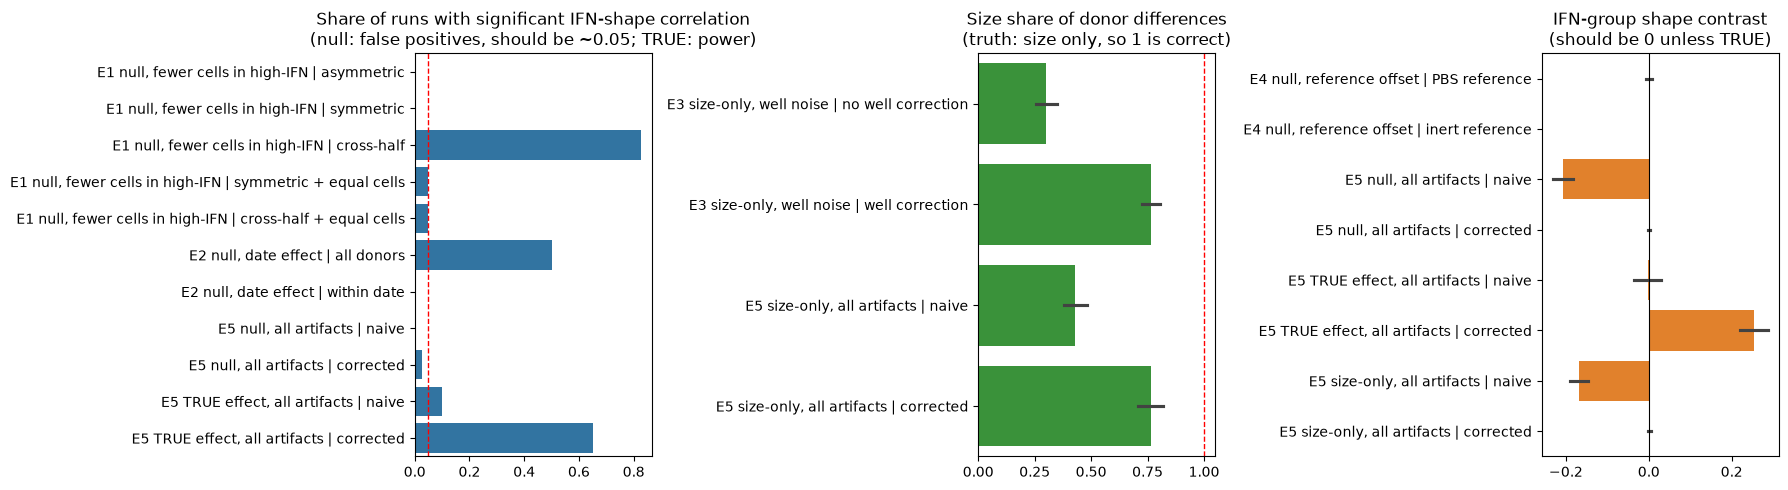

In [4]:
SHORT = {"E1 cell-count imbalance | null truth, fewer cells in high-IFN donors": "E1 null, fewer cells in high-IFN",
         "E2 processing date | null truth": "E2 null, date effect",
         "E3 well noise | truth: size only": "E3 size-only, well noise",
         "E4 reference offset | null truth": "E4 null, reference offset",
         "E5 all artifacts | null truth": "E5 null, all artifacts",
         "E5 all artifacts | true IFN shape effect": "E5 TRUE effect, all artifacts",
         "E5 all artifacts | truth: size only": "E5 size-only, all artifacts"}
d = ALL.copy(); d["label"] = d["experiment"].map(SHORT) + " | " + d["analysis"]
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sel = d[d.experiment.str.startswith(("E1", "E2")) | d.experiment.isin(["E5 all artifacts | null truth", "E5 all artifacts | true IFN shape effect"])]
sns.barplot(data=sel, y="label", x="sig_pos", ax=ax[0], errorbar=None, color="tab:blue")
ax[0].axvline(0.05, color="red", ls="--", lw=1)
ax[0].set_title("Share of runs with significant IFN-shape correlation\n(null: false positives, should be ~0.05; TRUE: power)"); ax[0].set_ylabel(""); ax[0].set_xlabel("")
sel = d[d.experiment.str.startswith("E3") | (d.experiment == "E5 all artifacts | truth: size only")]
sns.barplot(data=sel, y="label", x="share_size_typical", ax=ax[1], errorbar="sd", color="tab:green")
ax[1].axvline(1, color="red", ls="--", lw=1)
ax[1].set_title("Size share of donor differences\n(truth: size only, so 1 is correct)"); ax[1].set_ylabel(""); ax[1].set_xlabel("")
sel = d[d.experiment.str.startswith(("E4", "E5"))]
sns.barplot(data=sel, y="label", x="ifn_contrast_shape", ax=ax[2], errorbar="sd", color="tab:orange")
ax[2].axvline(0, color="k", lw=0.8)
ax[2].set_title("IFN-group shape contrast\n(should be 0 unless TRUE)"); ax[2].set_ylabel(""); ax[2].set_xlabel("")
plt.tight_layout(); fig.savefig(f"{RESULTS_DIR}/simulation_summary.png", dpi=150, bbox_inches="tight"); plt.show()

## Reading the results
- **E1 (cell-count imbalance):** when high-IFN donors have fewer cells, *every* estimator is biased, and the sign depends on the estimator (asymmetric and symmetric push shape down, cross-half pushes it up and gives many false positives). Equalizing cell counts across donors removes the bias.
- **E2 (processing date):** a minority date that raises the IFN score and shifts responses creates frequent false positives; comparing within dates removes them.
- **E3 (well noise):** when donors truly differ only in size, well noise makes them look different in shape (low size share); subtracting the well-noise estimate recovers most of the true size share.
- **E4 (reference offset):** a donor-specific offset in control wells adds spurious shape differences among typical donors; the inert reference removes it. Its effect on the IFN test is small here because the offset is unrelated to IFN.
- **E5 (all together):** the naive pipeline gives spurious group contrasts under the null and under size-only truth, and misses a real shape effect. The corrected pipeline (inert reference, cross-half estimator, within-date comparison, well correction, equal cell counts) keeps false positives near 5% and detects the real effect.